In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
df = df = pd.read_csv("/content/df_definitivo.csv")

#Analisi distribuzioni nel df prima dello split

In [ ]:
df.info()          # Tipo di variabili e valori nulli
df.describe()      # Statistiche per le variabili numeriche
df.describe(include='object')  # Statistiche per le variabili categoriche

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146332 entries, 0 to 146331
Data columns (total 61 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   originalTitle           146332 non-null  object 
 1   rating                  146332 non-null  int64  
 2   startYear               146332 non-null  int64  
 3   runtimeMinutes          146332 non-null  float64
 4   numVotes                146332 non-null  int64  
 5   totalCredits            146332 non-null  int64  
 6   criticReviewsTotal      146332 non-null  int64  
 7   numRegions              146332 non-null  int64  
 8   userReviewsTotal        146332 non-null  int64  
 9   companiesNumber         146332 non-null  int64  
 10  averageRating           146332 non-null  float64
 11  externalLinks           146332 non-null  int64  
 12  writerCredits           146332 non-null  int64  
 13  directorsCredits        146332 non-null  int64  
 14  quotesTotal         

,originalTitle
count,146332
unique,130191
top,Episode #1.1
freq,529


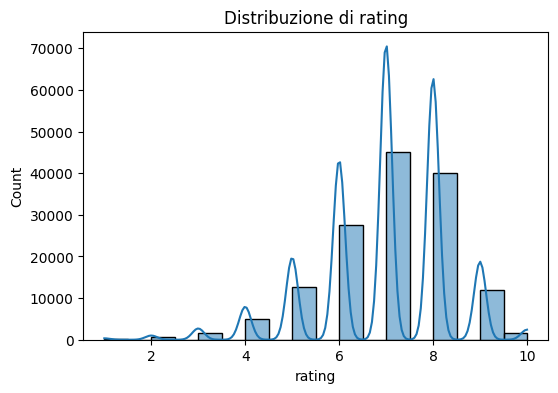

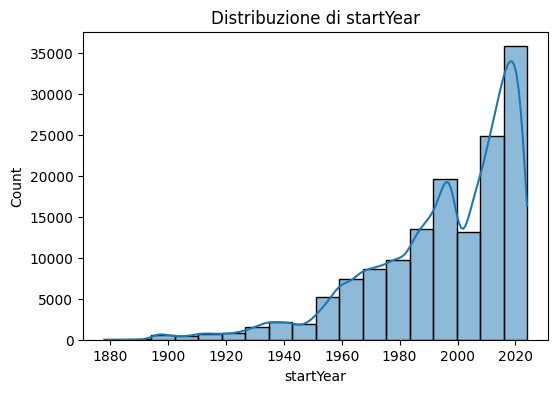

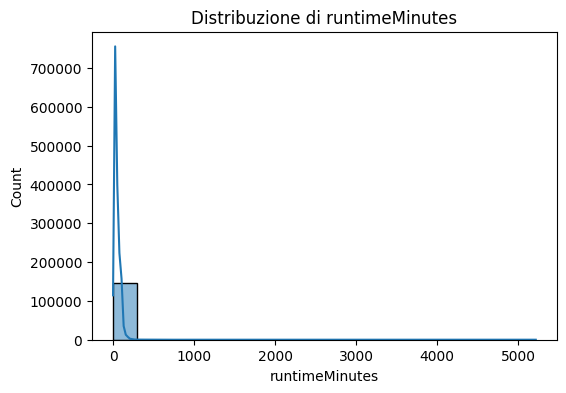

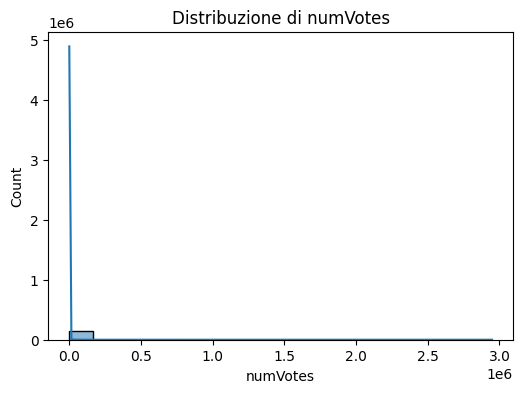

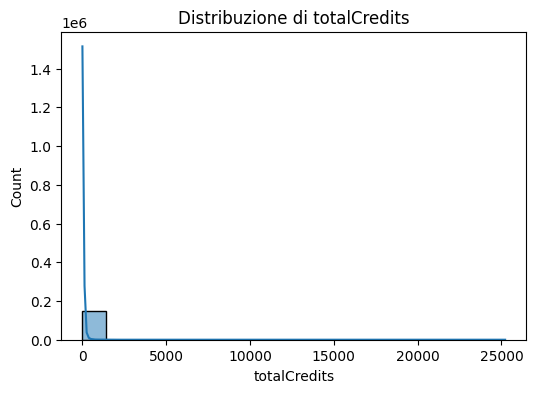

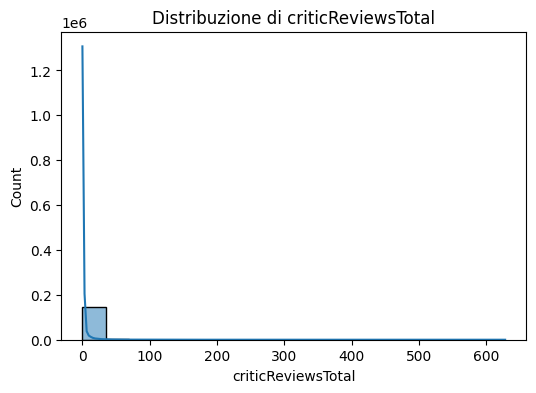

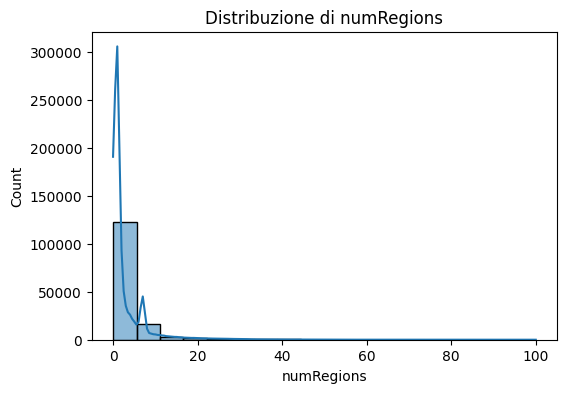

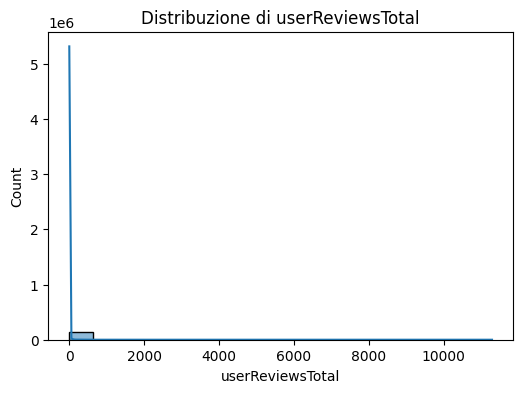

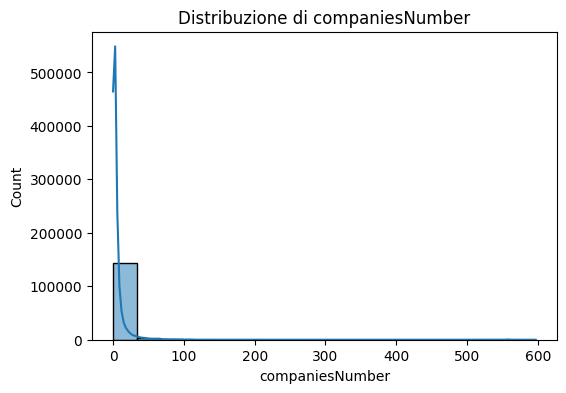

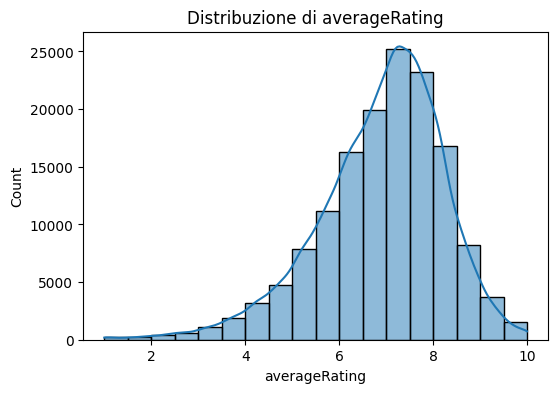

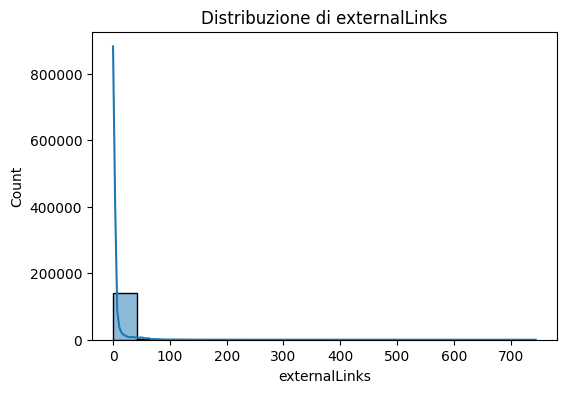

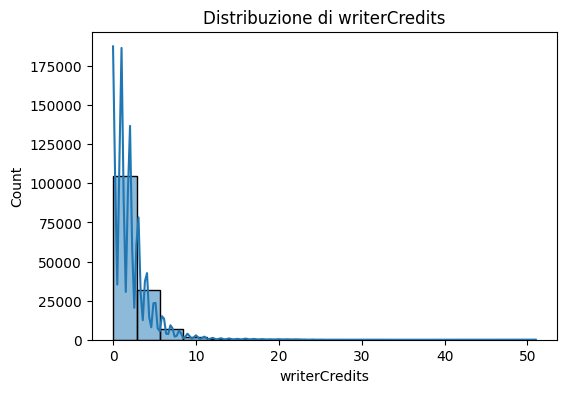

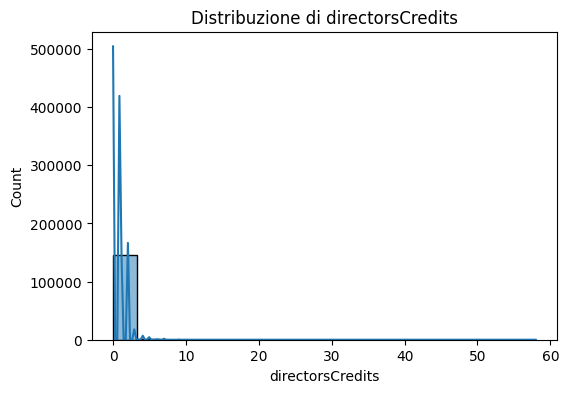

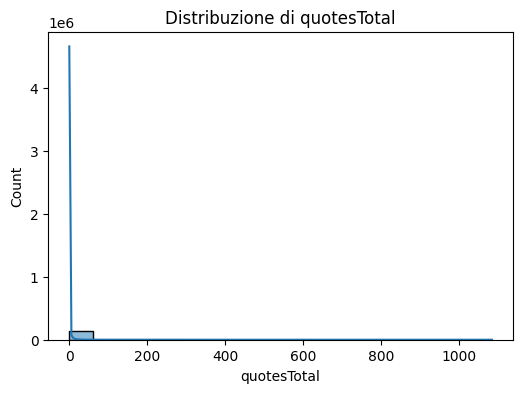

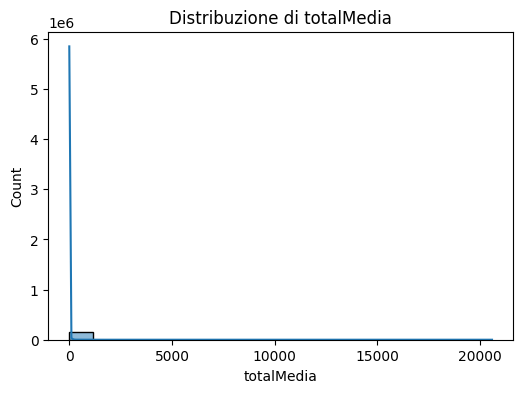

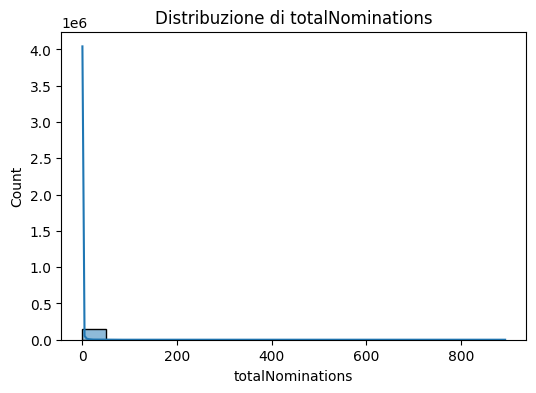

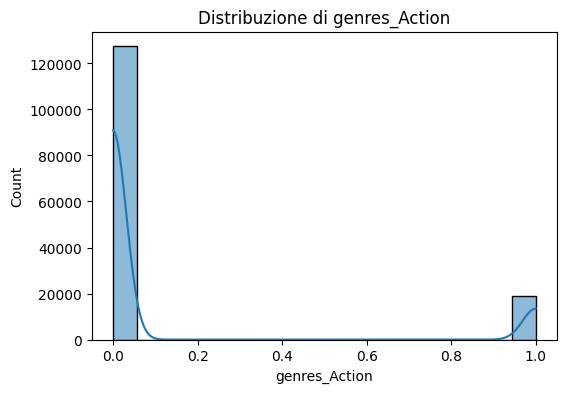

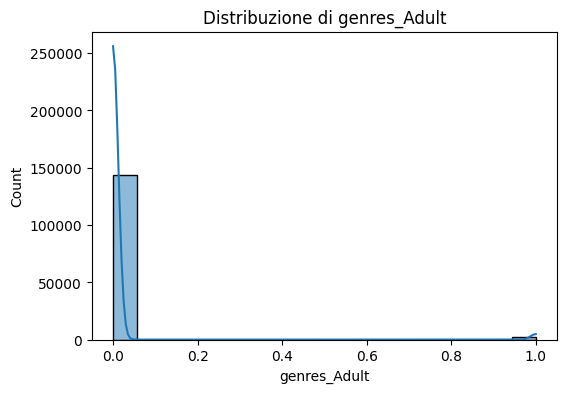

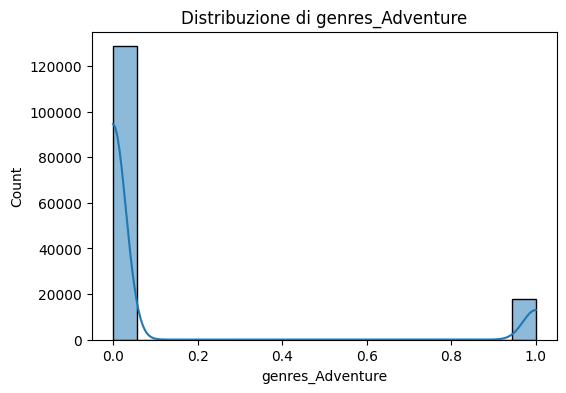

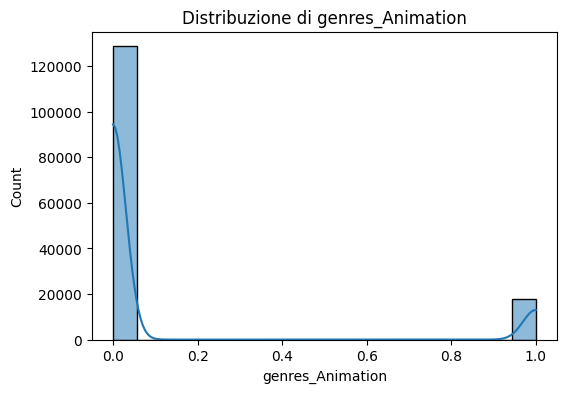

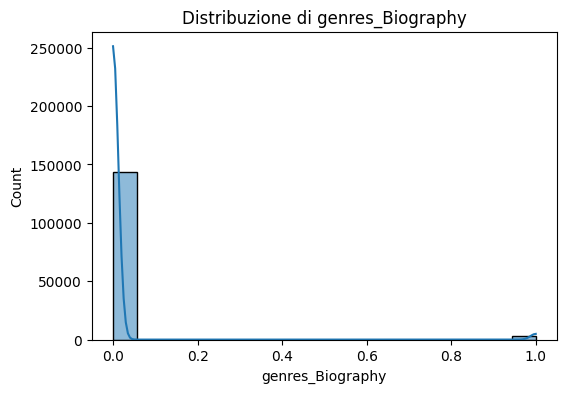

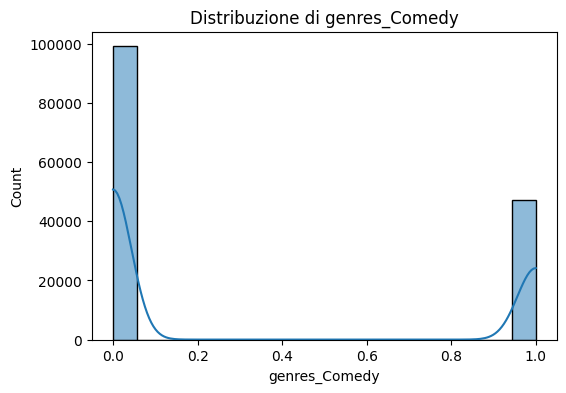

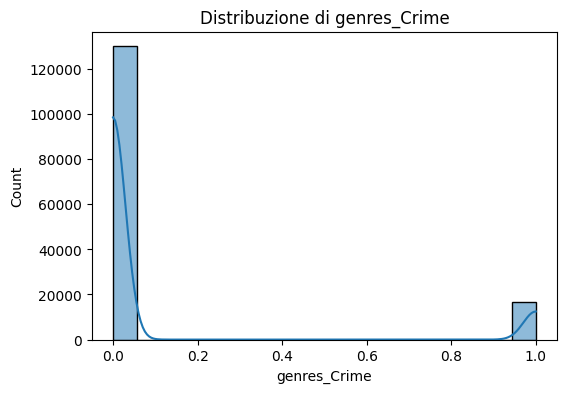

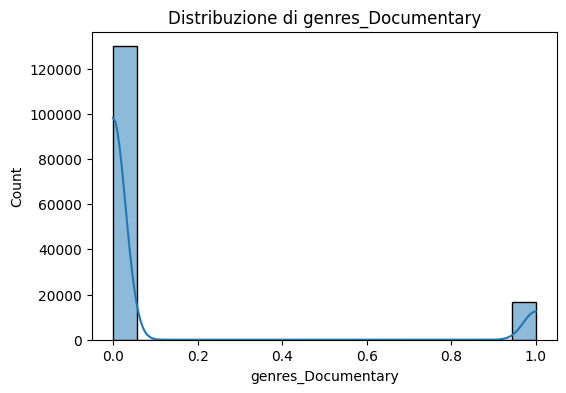

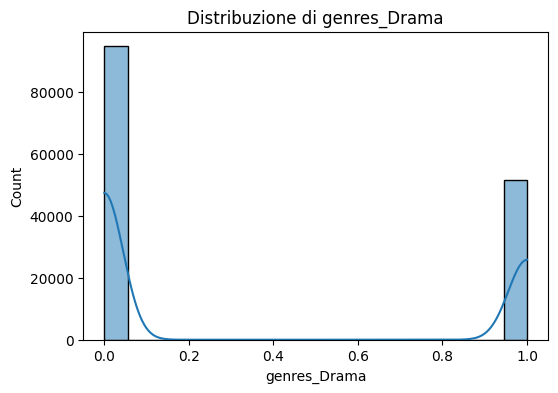

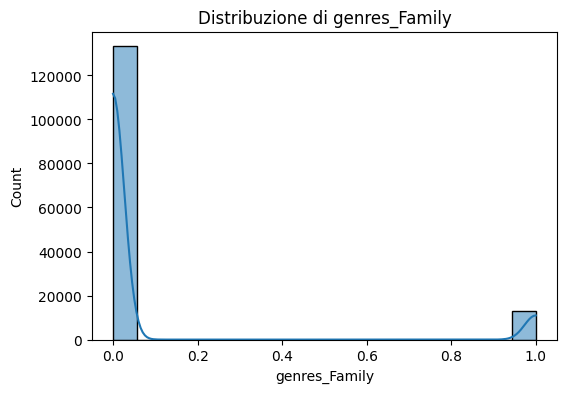

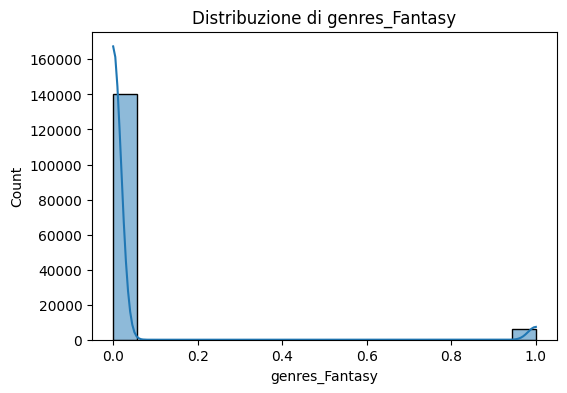

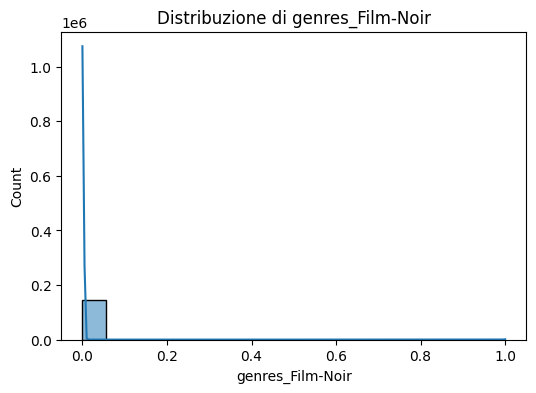

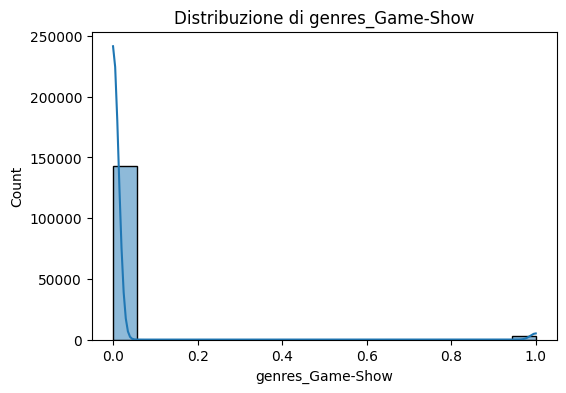

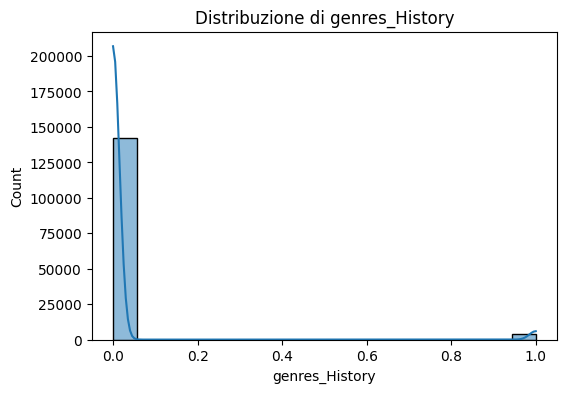

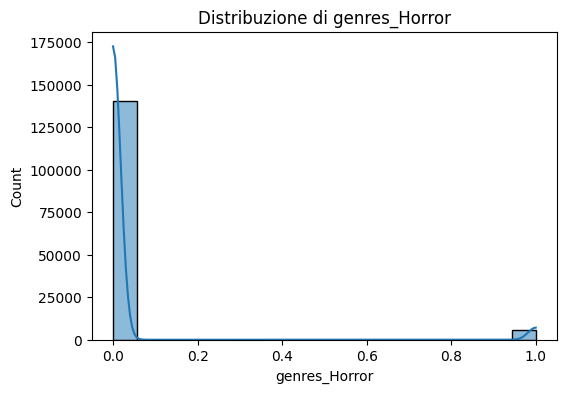

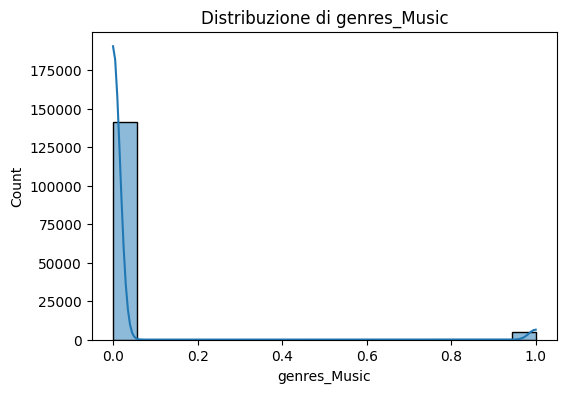

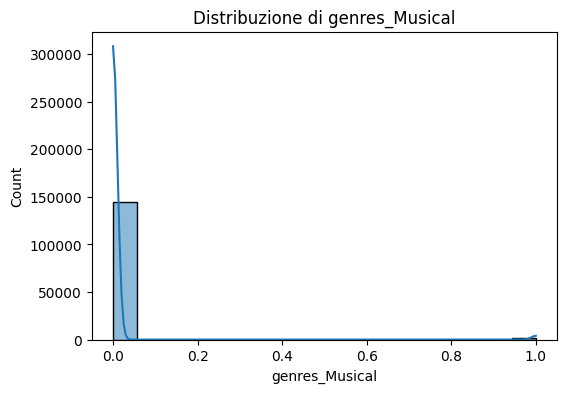

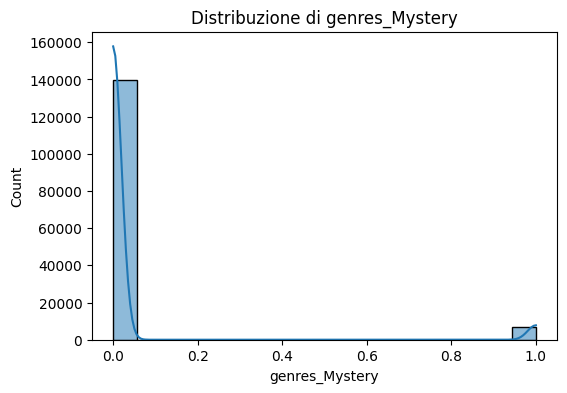

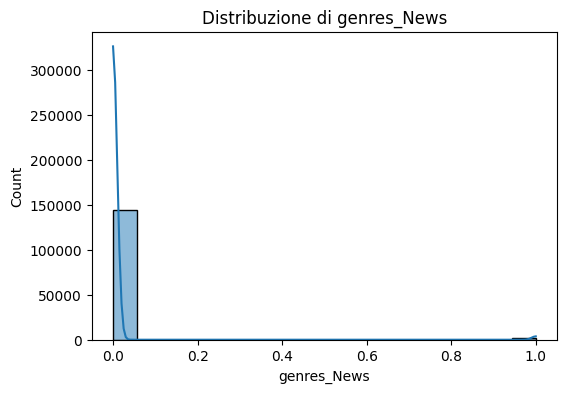

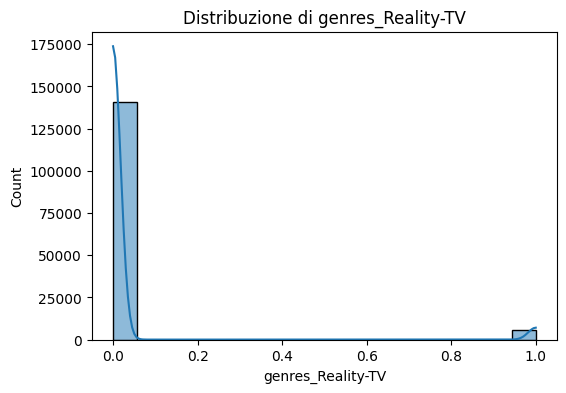

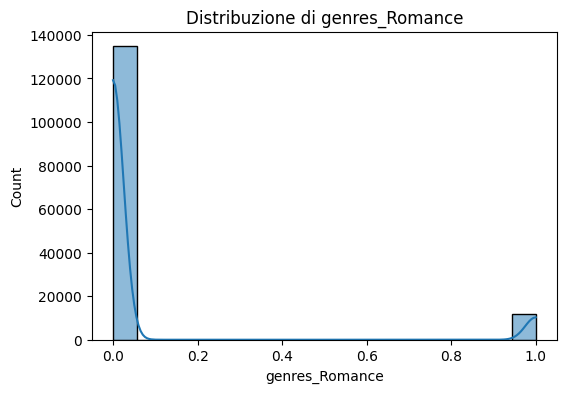

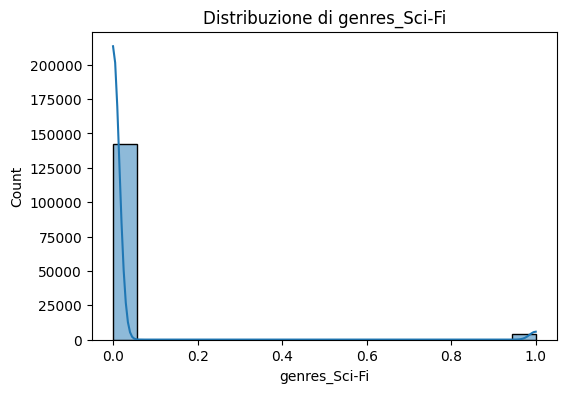

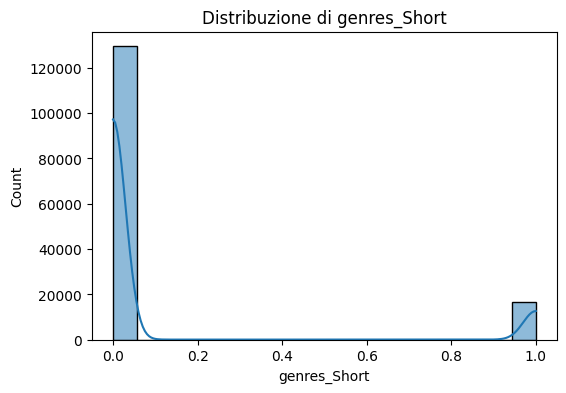

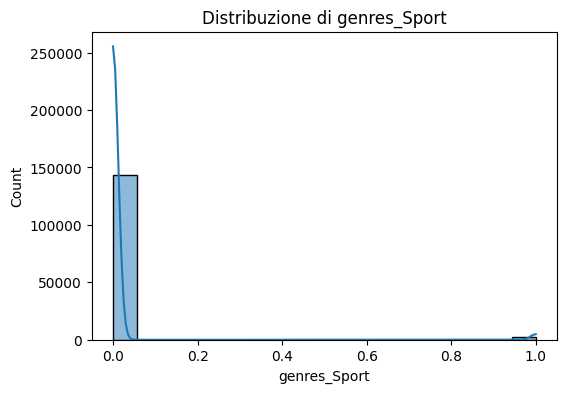

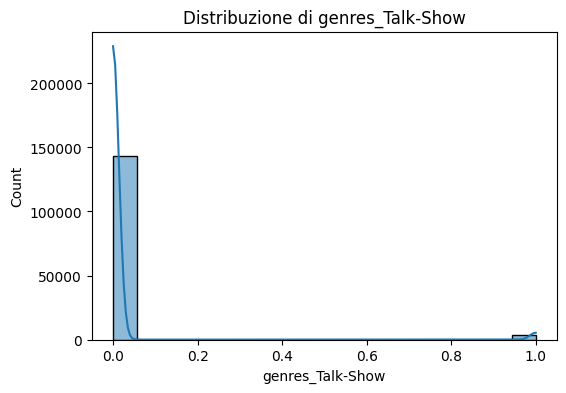

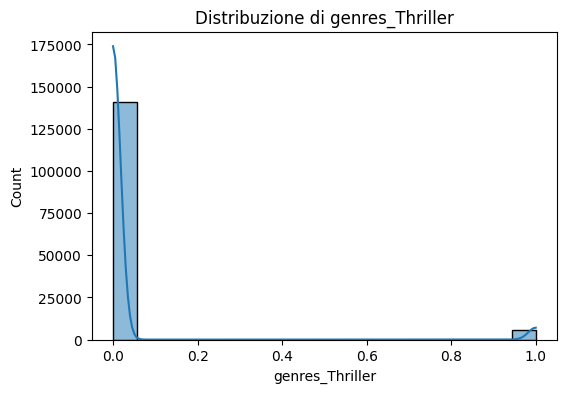

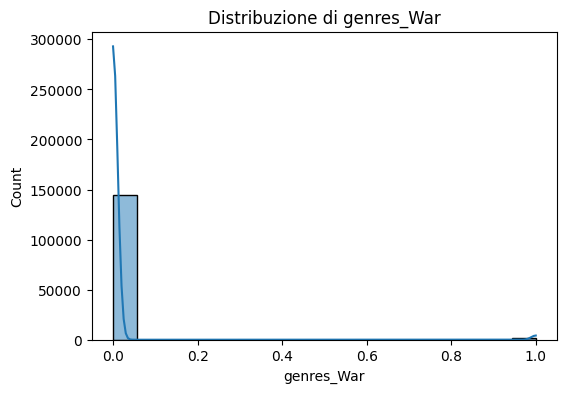

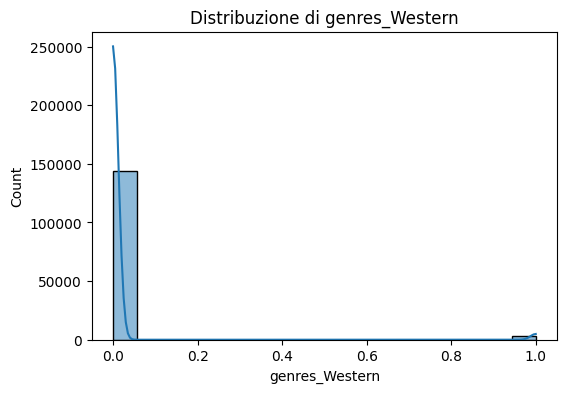

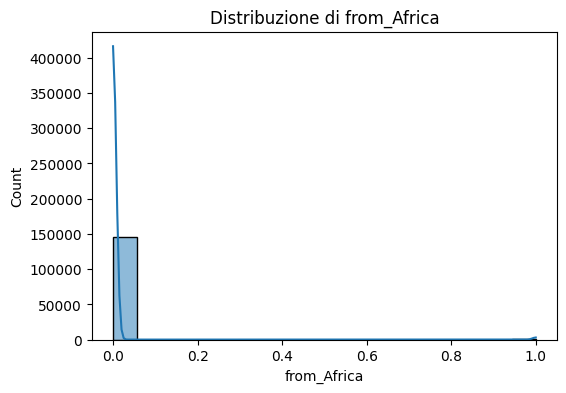

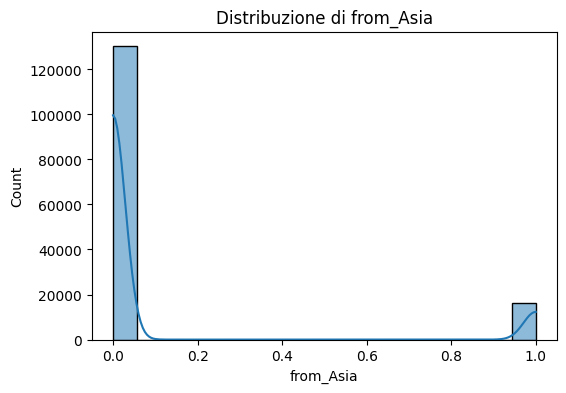

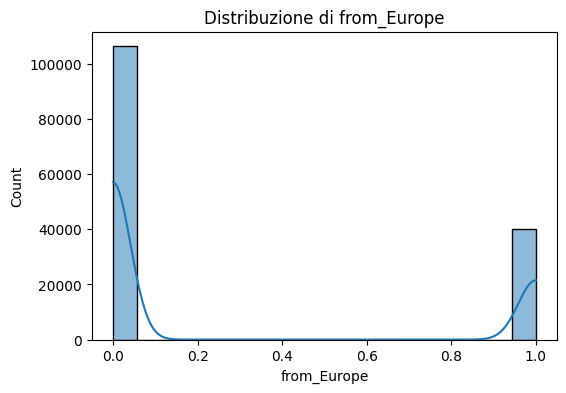

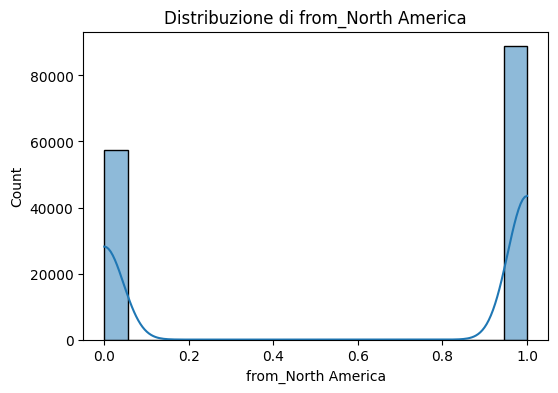

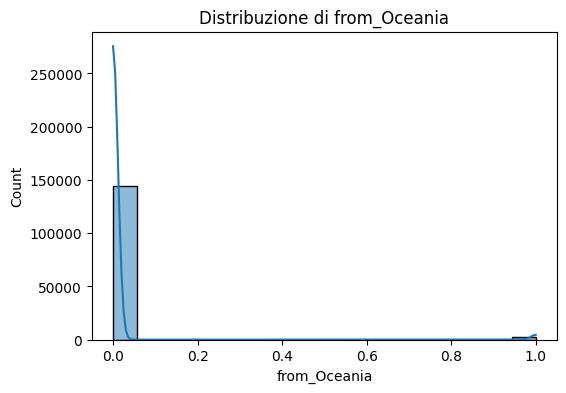

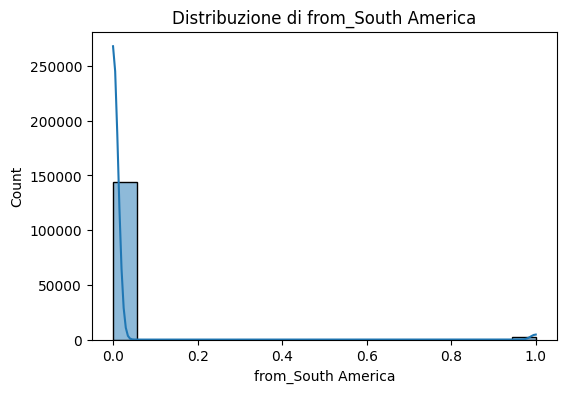

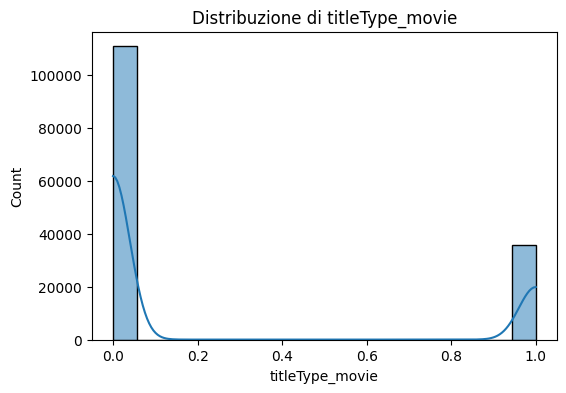

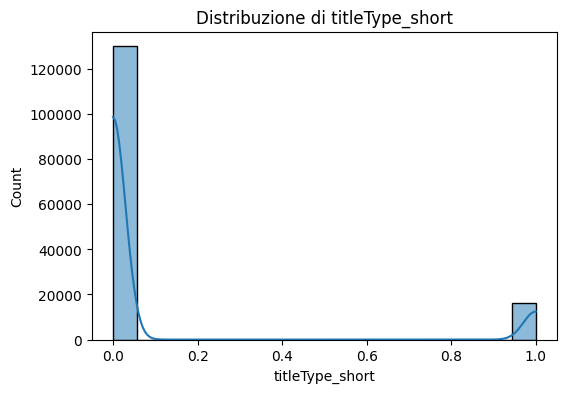

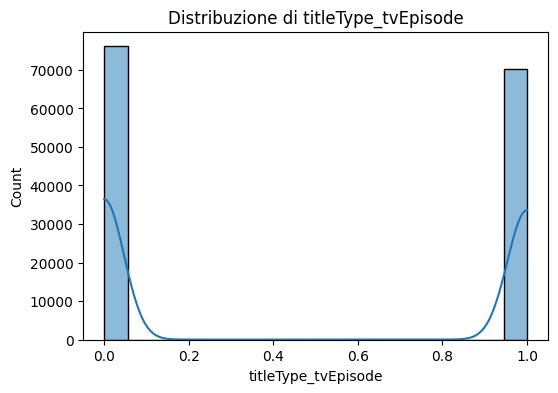

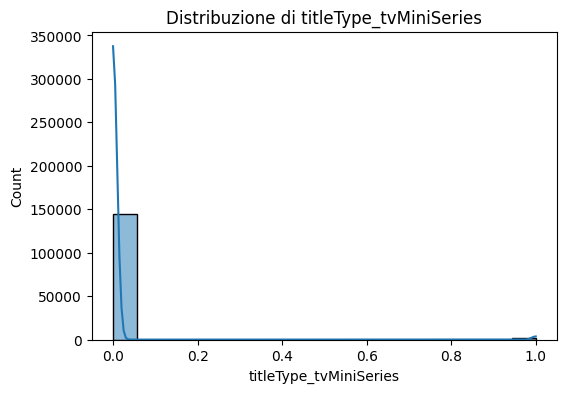

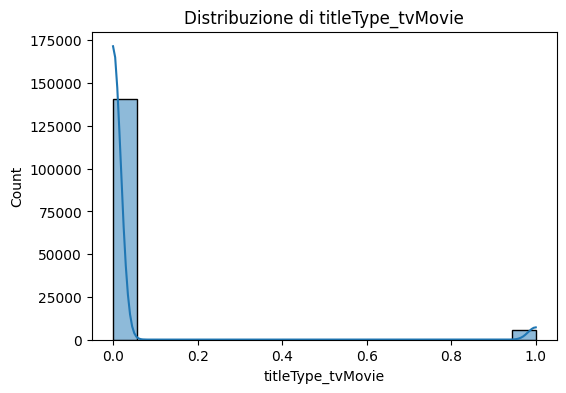

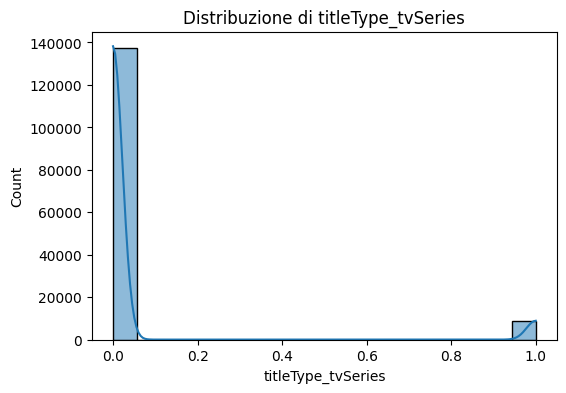

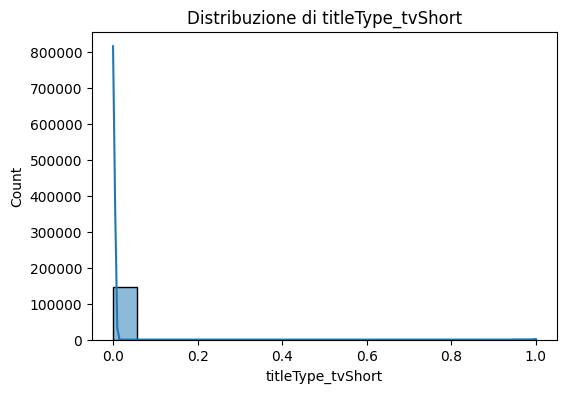

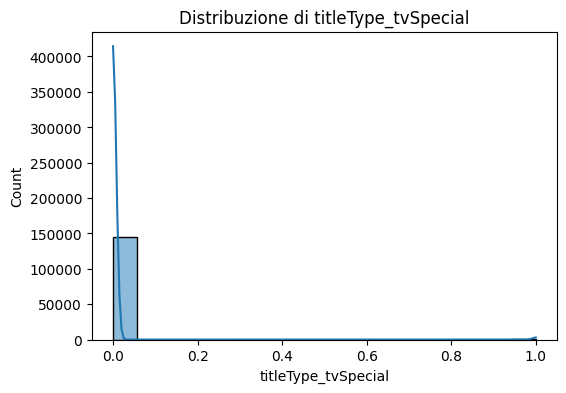

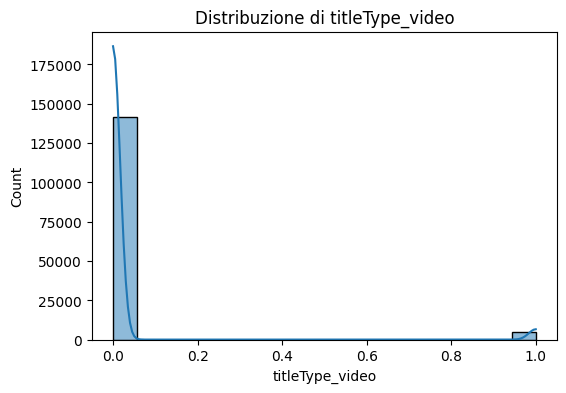

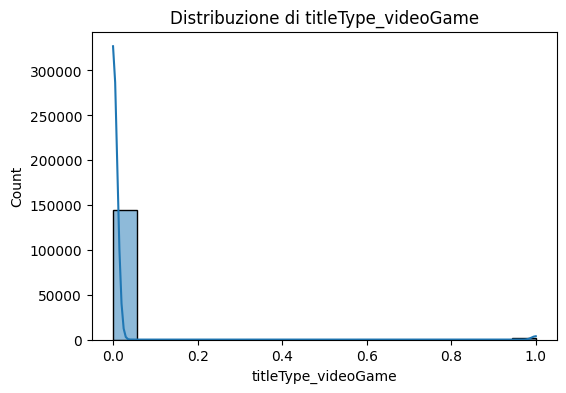

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeriche = df.select_dtypes(include=['int', 'float']).columns

for col in numeriche:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=18)
    plt.title(f'Distribuzione di {col}')
    plt.show()


In [ ]:
# Seleziona solo le colonne numeriche
numeriche = df.select_dtypes(include=['int', 'float'])

# Calcolo delle statistiche
statistiche = pd.DataFrame({
    'Minimo': numeriche.min(),
    'Massimo': numeriche.max(),
    'Media': numeriche.mean(),
    'Mediana': numeriche.median()
})

# Visualizza il risultato
print("Statistiche descrittive delle variabili numeriche:")
print(statistiche)

Statistiche descrittive delle variabili numeriche:
                        Minimo    Massimo        Media  Mediana
rating                     1.0       10.0     6.927630      7.0
startYear               1878.0     2024.0  1995.101386   2001.0
runtimeMinutes             0.0     5220.0    53.159951     45.0
numVotes                   5.0  2947931.0  1108.389095     29.0
totalCredits               0.0    25218.0    58.326730     35.0
criticReviewsTotal         0.0      628.0     2.237214      0.0
numRegions                 0.0      100.0     2.868621      1.0
userReviewsTotal           0.0    11289.0     5.688742      0.0
companiesNumber            0.0      597.0     5.912746      2.0
averageRating              1.0       10.0     6.881574      7.1
externalLinks              0.0      744.0     5.272688      1.0
writerCredits              0.0       51.0     2.023747      1.0
directorsCredits           0.0       58.0     0.949205      1.0
quotesTotal                0.0     1084.0     1.09058

#Train e Test Stratified per Title Type

##Ricostruzione+Label encoding di title type

In [ ]:
# Estrai i nomi delle colonne titleType (tutte quelle che iniziano con "titleType_")
title_cols = [col for col in df.columns if col.startswith('titleType_')]

# Ricostruisci la colonna categorica originale da one-hot
df['title_type'] = df[title_cols].idxmax(axis=1).str.replace("titleType_", "")



In [ ]:
label_mapping = dict(zip(lab_encoder.classes_, lab_encoder.transform(lab_encoder.classes_)))
print(label_mapping)


{'movie': np.int64(0), 'short': np.int64(1), 'tvEpisode': np.int64(2), 'tvMiniSeries': np.int64(3), 'tvMovie': np.int64(4), 'tvSeries': np.int64(5), 'tvShort': np.int64(6), 'tvSpecial': np.int64(7), 'video': np.int64(8), 'videoGame': np.int64(9)}


In [ ]:
# Ricostruisci la colonna categorica
titletype_onehot_cols = [col for col in df.columns if col.startswith("titleType_")]
df['title_type'] = df[titletype_onehot_cols].idxmax(axis=1).str.replace("titleType_", "")
# Droppa le colonne one-hot
df = df.drop(columns=titletype_onehot_cols)

ValueError: attempt to get argmax of an empty sequence

In [ ]:
df = df.drop(columns=['title_type'])
df =

In [ ]:
df= df.drop(columns=['originalTitle'])

In [ ]:
df.head()

,rating,startYear,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,numRegions,userReviewsTotal,companiesNumber,averageRating,...,genres_Thriller,genres_War,genres_Western,from_Africa,from_Asia,from_Europe,from_North America,from_Oceania,from_South America,titleType
0,6,1894,1.0,2089,4,3,7,16,3,5.7,...,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0,1
1,5,1892,12.0,183,2,0,6,1,0,5.4,...,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0,1
2,5,1894,1.0,195,1,0,5,0,1,5.0,...,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0,1
3,5,1894,1.0,2237,4,2,6,20,6,5.4,...,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0,1
4,7,1896,1.0,13115,11,16,21,66,5,7.4,...,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0,1


In [ ]:
# Prepara X e y
X_title = df.drop(['titleType'], axis=1)
y_title = df['titleType']

# Split stratificato su title_type
X_train_title, X_test_title, y_train_title, y_test_title = train_test_split(
    X_title, y_title,
    test_size=0.3,
    stratify=y_title,
    random_state=42
)


In [ ]:
# Ricomponi i dataset completi
train_title = X_train_title.copy()
train_title['title_type'] = y_train_title

test_title = X_test_title.copy()
test_title['title_type'] = y_test_title

# 🔽 Esportazione su CSV
train_title.to_csv("train_title.csv", index=False)
test_title.to_csv("test_title.csv", index=False)

In [ ]:
test_title.shape

(43900, 51)

#

In [ ]:
import pandas as pd

# Crea un DataFrame con le percentuali
dist_df = pd.DataFrame({
    'Full Set': y_title.value_counts(normalize=True),
    'Train Set': y_train_title.value_counts(normalize=True),
    'Test Set': y_test_title.value_counts(normalize=True)
}).sort_index()

print(dist_df)


#Train e Test Stratified per Rating

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146332 entries, 0 to 146331
Data columns (total 61 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   originalTitle           146332 non-null  object 
 1   rating                  146332 non-null  int64  
 2   startYear               146332 non-null  int64  
 3   runtimeMinutes          146332 non-null  float64
 4   numVotes                146332 non-null  int64  
 5   totalCredits            146332 non-null  int64  
 6   criticReviewsTotal      146332 non-null  int64  
 7   numRegions              146332 non-null  int64  
 8   userReviewsTotal        146332 non-null  int64  
 9   companiesNumber         146332 non-null  int64  
 10  averageRating           146332 non-null  float64
 11  externalLinks           146332 non-null  int64  
 12  writerCredits           146332 non-null  int64  
 13  directorsCredits        146332 non-null  int64  
 14  quotesTotal         

In [ ]:
# Prepara X e y
X_rating = df.drop(['rating', 'originalTitle'], axis=1)
y_rating = df['rating']

# Split stratificato su title_type
X_train_rating, X_test_rating, y_train_rating, y_test_rating, = train_test_split(
    X_rating, y_rating,
    test_size=0.3,
    stratify=y_rating,
    random_state=42
)


In [ ]:
# Ricomponi i dataset completi
train_rating = X_train_rating.copy()
train_rating['rating'] = y_train_rating

test_rating = X_test_rating.copy()
test_rating['rating'] = y_test_rating

# 🔽 Esportazione su CSV
train_rating.to_csv("train_rating.csv", index=False)
test_rating.to_csv("test_rating.csv", index=False)

In [ ]:
test_rating.shape

(43900, 60)

In [ ]:
# Calcola le distribuzioni percentuali
dist_rating = pd.DataFrame({
    'Full Set': y_rating.value_counts(normalize=True),
    'Train Set': y_train_rating.value_counts(normalize=True),
    'Test Set': y_test_rating.value_counts(normalize=True)
}).sort_index()


# Mostra a schermo
print("✔️ Distribuzioni di 'rating' esportate in 'rating_distribution.csv':")
print(dist_rating)


✔️ Distribuzioni di 'rating' esportate in 'rating_distribution.csv':
        Full Set  Train Set  Test Set
rating                               
1       0.001449   0.001445  0.001458
2       0.004367   0.004364  0.004374
3       0.011754   0.011754  0.011754
4       0.034449   0.034452  0.034442
5       0.085853   0.085852  0.085854
6       0.187840   0.187842  0.187836
7       0.308859   0.308859  0.308861
8       0.273296   0.273294  0.273303
9       0.081629   0.081635  0.081617
10      0.010504   0.010505  0.010501
